# In-Class Assignment: Agent Based Modeling of Superbugs (part 2)
## With more code review!
# Day 09
# CMSE 202

<img src="https://raw.githubusercontent.com/s-macke/Abstruse-Goose-Archive/refs/heads/master/comics/you_down_wit_OPC-yeah_you_know_me.png" width=600px>
<p style="text-align: right;">
    
Source: http://abstrusegoose.com/strips/you_down_wit_OPC-yeah_you_know_me.png ; thanks to Bruce Bolden</p>

<!--
<img src="http://abstrusegoose.com/strips/you_down_wit_OPC-yeah_you_know_me.png" width=600px>
<p style="text-align: right;">Amusing comic from: http://abstrusegoose.com/ </p>
-->

### <p style="text-align: right;"> &#9989; **Jaehan Kim** </p>
#### <p style="text-align: right;"> &#9989; Akshita, Ahmed, Taliah</p>

## Agenda for today's class

- [Part 1: Pre-class assignment review and discussion](#pca-review)
- [Part 2: Revisiting your assignment from last class, building your Python class(es)](#revisit)
- [Part 3: Understanding someone else's code](#someone-else)
- [Part 4: Reviewing the provided code](#code-review)
- [Part 5: Running the simulation](#simulation)
- [Part 6: Testing Scientific Questions](#testing)

---
<a id="pca-review"></a>
## Part 1. Pre-class assignment review and discussion

Did anyone have any specific issues with the pre-class assignment?

Let's take a moment to highlight some key concepts. **Discuss with your group** the following prompts and write down a some brief notes from your discussion.

&#9989; **Question 1:** What did you see as some of the key differences, advantages, and disadvantages in the linear, functional, and object oriented programming approaches you reviewed in the pre-class assignment?

<font size=+3>&#9998;</font> Linear code is simple, but it can get messy. Functional code is more organized because it uses functions. Object-oriented code is useful because each object can store its own data and methods.

&#9989; **Question 2:** What is a Python "docstring", how it is used, and why is it useful?

<font size=+3>&#9998;</font> Linear code is simple, but it can get messy. Functional code is more organized because it uses functions. Object-oriented code is useful because each object can store its own data and methods.

---
<a id="revisit"></a>
##  Part 2. Revisiting your assignment from last class, building your Python class(es)

Now that you've had a bit more time to think about objected oriented programming and review some code that was written to build an agent-based model in an objected oriented way, **you're going to spend the first 15 minutes of your group activity time picking up where you left off with your "superbugs" model.**

**&#9989; Do This:** Take this time to review the progress you made last class on initializing your petri dish. If you didn't finish it, try to finish it. If you finished it, review your code and think about ways you might be able to make it better. Reviewing your own code will sometimes feel like looking at someone else's code. You might find that your "present self" isn't a huge fan of how your "past self" did things (especially if your past self didn't leave you any comments!). **Do this as a group!**

Copy your code from last time into this notebook and try to get your petri dish code working or make improvements to a functioning version.

**If you already managed to get the basic petri dish initialization working, start building other methods that would be necessary to evolve the model**.

**If you do not get your own code working within the first 15 minutes, move on to part 3 and download a working version of the code.** 

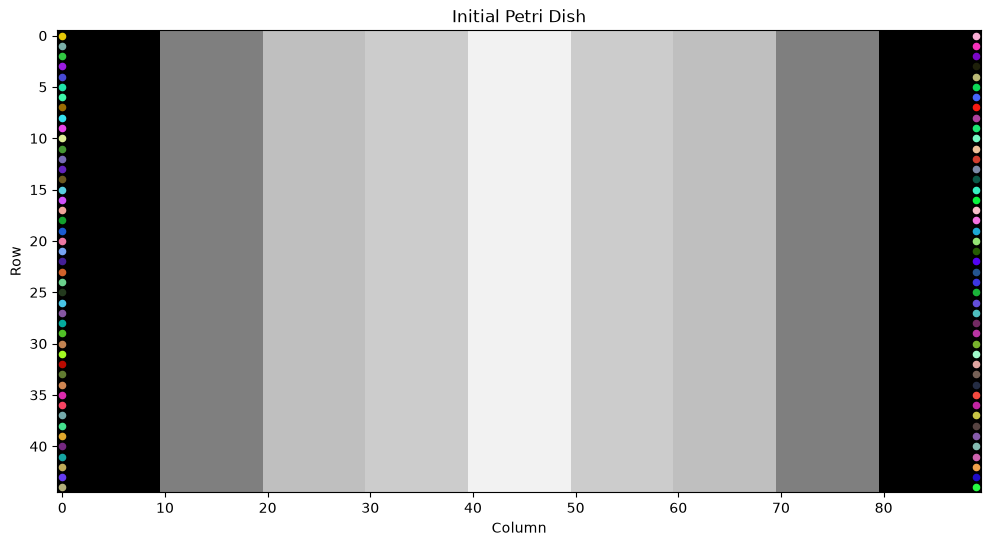

In [1]:
# CODE GOES HERE!
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import random

class Bacteria:
    def __init__(self, row, col, genes=None):
        self.row = row
        self.col = col
        
        if genes is None:
            self.genes = np.random.random(3)
        else:
            self.genes = genes
            
        self.alive = True

    def get_color(self):
        return self.genes


class World:
    def __init__(self, n_rows=45, n_cols=90):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.antibiotics = np.zeros((n_rows, n_cols, 3))
        self.bacteria = []
        self.setup_antibiotics()
        self.setup_bacteria()

    def setup_antibiotics(self):
        levels = [0.0, 0.50, 0.75, 0.80, 0.95, 0.80, 0.75, 0.50, 0.0]
        bin_width = self.n_cols // len(levels)

        for i in range(len(levels)):
            start = i * bin_width
            end = (i + 1) * bin_width
            self.antibiotics[:, start:end, :] = levels[i]

    def setup_bacteria(self):
        for row in range(self.n_rows):
            self.bacteria.append(Bacteria(row, 0))
            self.bacteria.append(Bacteria(row, self.n_cols - 1))

    def draw(self):
        plt.figure(figsize=(12, 6))
        plt.imshow(self.antibiotics)

        for bug in self.bacteria:
            plt.scatter(
                bug.col,
                bug.row,
                color=bug.get_color(),
                s=20
            )

        plt.title("Initial Petri Dish")
        plt.xlabel("Column")
        plt.ylabel("Row")
        plt.show()


world = World()
world.draw()

## &#128721; STOP

Check-in with the rest of the group and with the instructor

----
<a id="someone-else"></a>
## Part 3. Understanding someone else's code

In the pre-class assignment, you spent some time doing a code review of multiple solutions to the same problem. In addition to simply reading unfamiliar code to make sense of it, when we use a new bit of code, if it's reasonably well written there are ways to explore how it works from inside our Jupyter notebooks or within an IPython prompt as well.

Thus far you've been a bit of time trying to write your own solution to the superbug problem in an effort to recreate the anti-bacterial resistance experiment. Maybe you got everything working the way you wanted, or perhaps you've still ironing out a few bugs. **Now we're going to switch gears a bit and look at one possible complete solution to the problem**.

**&#9989; Do This:** To start, you're going to import a script that contains this solution. First, you need to download the script, `superbugs.py`, which you can get here:

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/code_samples/superbugs.py`

**Run the following cell to import the script once you download it.**

In [3]:
!curl -O https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/code_samples/superbugs.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8107  100  8107    0     0  67235      0 --:--:-- --:--:-- --:--:-- 67558


In [4]:
import superbugs

&#9989; **Do This:** Now, explore the above software, but **don't just look at the code right now**. Use standard exploration commands (e.g. use `help()`, `dir()`, `type`, or `?`) in your notebook to see if you can figure out what "`superbugs`" does/can do. 

In [5]:
# put your exploration code here.
superbugs

<module 'superbugs' from '/home/kimjaeha/CMSE 202/Day-9-0714/superbugs.py'>

&#9989; **Do This:** Using the superbugs code, initialize the experiment and display the first time step of the board (t=0). Then, try to take a timestep and visualize the result. Again, **see if you can do this _without_ looking at the source code**.

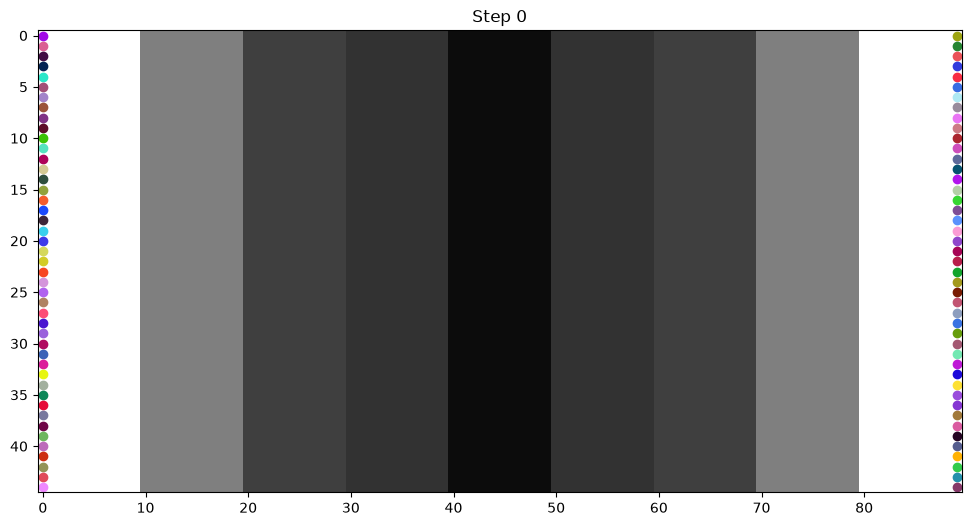

In [6]:
# put your initialization and visualization code here
import matplotlib.pyplot as plt

petri_dish = superbugs.PetriDish()

plt.figure(figsize=(12, 6))
petri_dish.draw()
plt.title("Step 0")
plt.show()

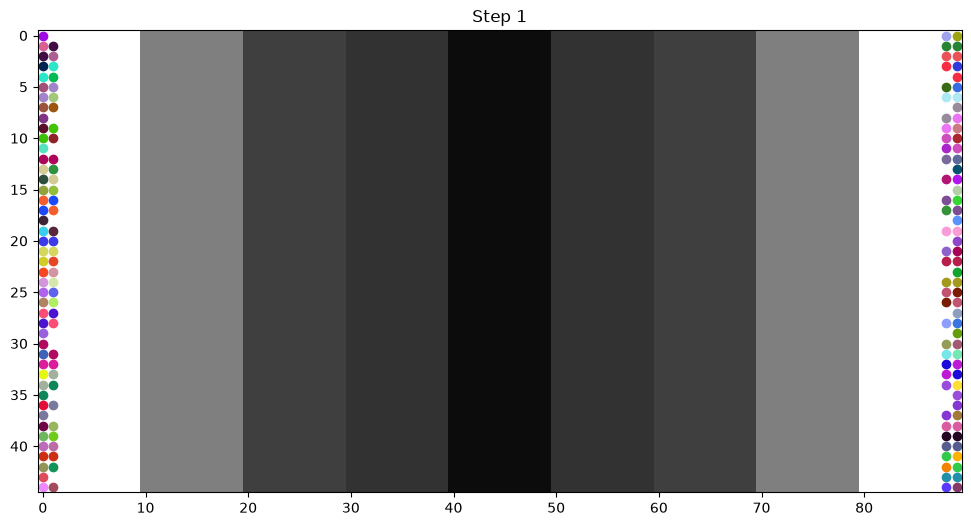

In [7]:
# put your code for taking a step and visualizing the code here
petri_dish.timestep()

plt.figure(figsize=(12, 6))
petri_dish.draw()
plt.title("Step 1")
plt.show()

---
<a id="code-review"></a>
## Part 4. Reviewing the provided code

OK, now that you've managed to learn a bit about the the code to the point where you can initialize the simulation, you're going to take a look at the code and see how it compares to what you came up with.

&#9989; **Do This:** Open `superbugs.py` in a text editor and review the code. How does it work, what classes are available? What are their associated methods and attributes? **Compare and constrast the code with the code that you wrote** (even if you didn't get all bits of your code working). **What parts are similar? What parts are different? What advantages/disadvantages do you see in your approach and this approach?** Discuss this with your group and write down some notes from your discussion.

**If there are parts of the code that you don't understand, talk with your group or ask an instructor for help!**

<font size=+3>&#9998;</font> The provided code uses a Bug class and a PetriDish class. My code was similar because it also used bacteria and a world. The provided code is better because it already has mutation, survival, and timesteps working.

## &#128721; STOP

Check-in with the rest of the group and with the instructor.

----
<a id="simulation"></a>
## Part 5. Running the Simulation

Now that you understand a bit about how the code works, you're going to try to run a full simulation for a set number of timesteps.

&#9989; **Do This:** Using the petri_dish variable you initialized previously, write an loop that runs the ```timestep``` function followed by the ```draw``` function 10 times.  Make sure to animate the figure (you might need to dig up a previous example to get the animation working).

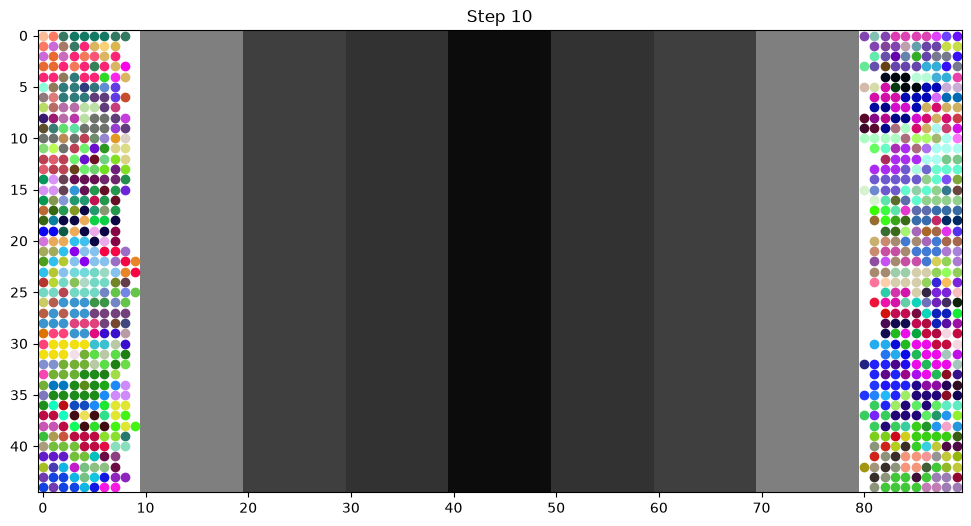

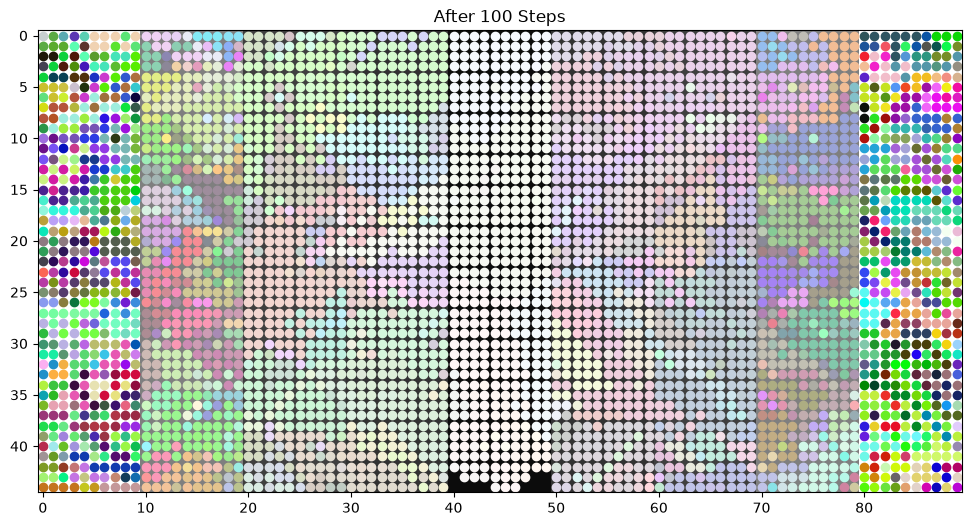

In [9]:
# Put your code here
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

petri_dish = superbugs.PetriDish()

for i in range(10):
    petri_dish.timestep()
    
    clear_output(wait=True)
    plt.figure(figsize=(12, 6))
    petri_dish.draw()
    plt.title("Step " + str(i + 1))
    plt.show()
    
    time.sleep(0.2)

petri_dish = superbugs.PetriDish()

for i in range(100):
    petri_dish.timestep()

plt.figure(figsize=(12, 6))
petri_dish.draw()
plt.title("After 100 Steps")
plt.show()

&#9989; **Do This:** You might have noticed that the simulation gets slower as it runs.  **Comment out the plotting and animation code and rerun the simulation with 100 iterations.** Only draw the simulation once it is complete.

&#9989; **Question 3**: Do you notice a change in the simulation run time when you comment out the plotting and animation code? How can you tell?

<font size=+3>&#9998;</font> Yes, it runs faster without plotting and animation. I can tell because the code finishes more quickly.


&#9989; **Do This**: Now consider an optimized version of the Superbugs code. Download the code from the url below. And then attempt to run a new simulation with 100 generations while animating it each generation, similar to the beginning of part 5. 

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/code_samples/superbugsOpt.py`

In [13]:
!curl -O https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/code_samples/superbugsOpt.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8631  100  8631    0     0   219k      0 --:--:-- --:--:-- --:--:--  221k


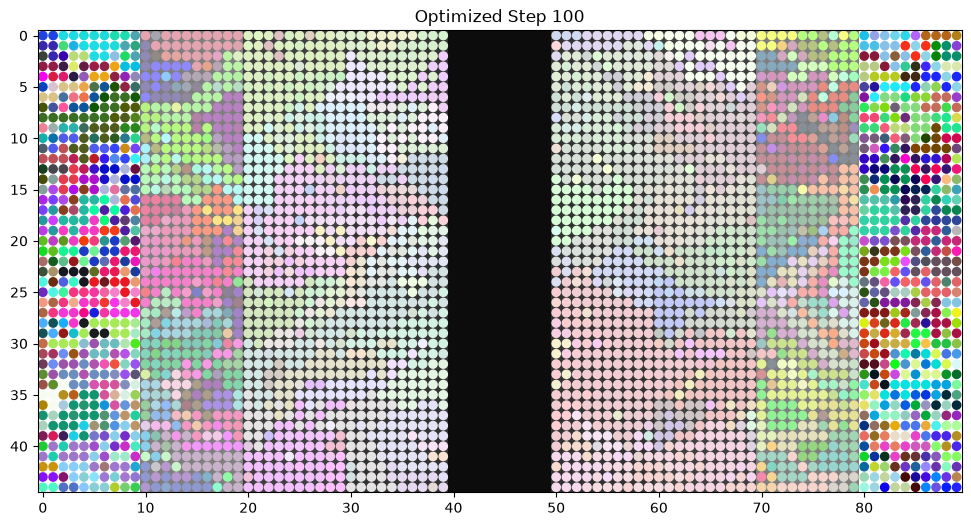

In [14]:
import superbugsOpt
import importlib

importlib.reload(superbugsOpt)

petri_dish = superbugsOpt.PetriDish()

for i in range(100):
    petri_dish.timestep()
    
    clear_output(wait=True)
    plt.figure(figsize=(12, 6))
    petri_dish.draw()
    plt.title("Optimized Step " + str(i + 1))
    plt.show()
    
    time.sleep(0.05)

&#9989; **Question 4**: How much faster did the code run compared to the original animated version? Looking at the new code, why do you think it ran faster? 

<font size=+3>&#9998;</font> The optimized code ran faster than the original animated version. I think it was faster because it draws all bugs together instead of drawing each bug one by one.


&#9989; **Question 5**: What if you wanted to know exactly how long it took to run the simulation? You might have used the `time` module in your animation code or in previous code you've worked with, but we can also use it to time how long certain pieces of code take to run. We can record an initial time with something like:

`start = time.time()`

And then record the time the code finishes with:

`end = time.time()`

Try adding this to your code above to time exactly how long the simulation took in each scenario. Add a line to **print the difference between end and start time to get the total runtime (in seconds)**. Try comparing the total run times between the first version, the version without the animation, and the optimized version.

**What is the difference in the timing between the versions explored?**

<font size=+3>&#9998;</font> The original animated version was the slowest. The original version without animation was faster. The optimized animated version was also faster because the drawing code was improved.


&#9989; **Question 6**: What if you wanted to know how long each step of the simulation took (i.e. each iteration of the loop)? How would you track this information in your code? **If you have time at the end of class, come back to this and try implementing some code that tracks the time that each step took and prints or visualizes the results.**

<font size=+3>&#9998;</font> I would make a list called step_times. For each step, I would record the start time and end time, then save the difference.

---
<a id="testing"></a>
## Part 6. Testing Scientific Questions

For the remainder of the class, we are going to use this code to ask some scientific questions.

&#9989; **Do This:** Discuss as a group/class the types of scientific question can you could ask (and potentially answer) using this type of simulation.  

<font size=+3>&#9998;</font> We could ask how mutation rate affects how quickly bacteria spread across the petri dish.

&#9989; **Question 7:** Given the above questions, what types of measurements or modifications might we need to add to the superbug code? 

<font size=+3>&#9998;</font> We would need to measure how far the bacteria spread over time. We could also track the number of living bacteria each step.

### Visualizing the progress of the superbugs

If we wanted to use this simulation to answer one of your scientific questions, we might want to visualize the progress of the superbugs as a function of time as they march across the petri dish.

&#9989; **Do This:** Write some code to show, in one graph, the progress of the simulation.  For example: you could plot the number of iterations on the x axis and the progress the bugs have made toward the center of the simulation on the y axis.  

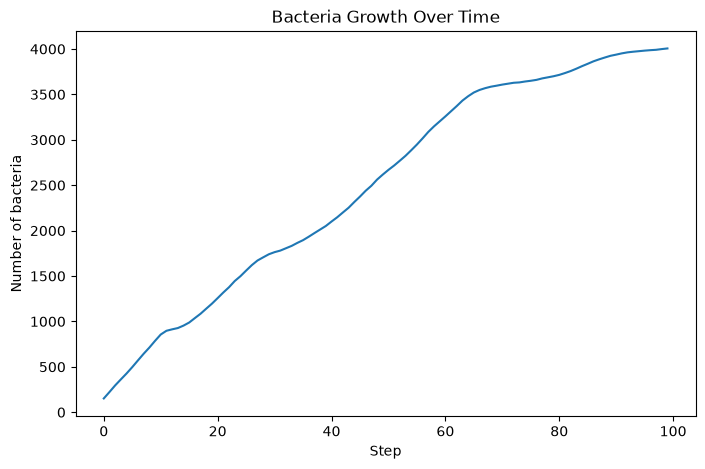

In [15]:
#Put your code here.
petri_dish = superbugs.PetriDish()

steps = []
num_bugs = []

for i in range(100):
    petri_dish.timestep()
    
    steps.append(i)
    num_bugs.append(len(petri_dish.buglist))

plt.figure(figsize=(8, 5))
plt.plot(steps, num_bugs)
plt.xlabel("Step")
plt.ylabel("Number of bacteria")
plt.title("Bacteria Growth Over Time")
plt.show()

&#9989; **Do This:** Do this, modify or use the simulation in some way that allows you to test a scientific question of the simulation.  

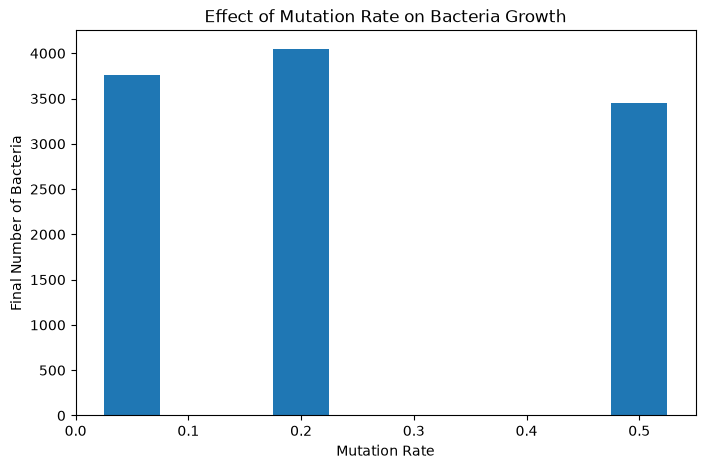

In [16]:
# put your scientific experiment code here.
mutation_rates = [0.05, 0.2, 0.5]
final_counts = []

for rate in mutation_rates:
    petri_dish = superbugs.PetriDish(bug_mutation_rate=rate)
    
    for i in range(100):
        petri_dish.timestep()
    
    final_counts.append(len(petri_dish.buglist))

plt.figure(figsize=(8, 5))
plt.bar(mutation_rates, final_counts, width=0.05)
plt.xlabel("Mutation Rate")
plt.ylabel("Final Number of Bacteria")
plt.title("Effect of Mutation Rate on Bacteria Growth")
plt.show()

&#9989; **Question 8**: What scientific question does your new usage or modification demonstrate and what can you conclude from the simulation?

<font size=+3>&#9998;</font> My question is how mutation rate affects bacteria growth. From the simulation, higher mutation rates may help bacteria survive stronger antibiotics, but the result can change because the simulation is random.

-----
### Congratulations, we're done!

Now, you just need to submit this assignment by uploading it to the course <a href="https://d2l.msu.edu/">Desire2Learn</a> web page for today's submission folder (Don't forget to add your names in the first cell).


&#169; Copyright 2025, Department of Computational Mathematics, Science and Engineering at Michigan State University